# HMDA Capstone — Transparency Analysis Part

**Group 4 | Member: Hassan**

### This notebook covers:
1. CP Plot, ICE, c-ICE, d-ICE
2. LIME
3. Counterfactual Explanations (DiCE)
4. Shapley Values (SHAP)


## Step 0 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install shap lime dice-ml lightgbm duckdb

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import duckdb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, classification_report

pd.set_option("display.max_columns", None)
shap.initjs()
print("All libraries loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 96.1 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=811ea3dd7f2fbd22c3940f67eb5390c8eff162cedea85c029a68edce8d2cb496
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


All libraries loaded.


## Step 1 — Load Data


In [ ]:
file_path = '/content/drive/MyDrive/RML_Capstone/2024_lar.txt'

# DuckDB: for fast loading
conn = duckdb.connect()
raw_data = conn.execute(f"""
    SELECT
        action_taken, income, loan_amount, debt_to_income_ratio,
        loan_term, loan_type, loan_purpose,
        combined_loan_to_value_ratio, property_value,
        applicant_credit_score_type,
        tract_minority_population_percent,
        derived_race, derived_sex
    FROM read_csv(
        '{file_path}',
        delim='|', header=true,
        sample_size=-1, ignore_errors=true
    )
""").df()

print(f"Rows loaded: {raw_data.shape[0]:,}")
print(f"Columns:     {raw_data.shape[1]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 12,259,119
Columns:     13


### 1.1 — Target Construction

We create a binary label from the `action_taken` column:

| `action_taken` | Meaning | Label |
|---|---|---|
| 1 | Loan originated | **1 (Approved)** |
| 2 | Approved but not accepted | **1 (Approved)** |
| 3 | Application denied | **0 (Denied)** |
| Other | Withdrawn, incomplete, etc. | **Filtered out** |

In [3]:
df = raw_data.replace(['NA', 'Exempt'], np.nan).copy()
df['action_taken'] = pd.to_numeric(df['action_taken'], errors='coerce')
df = df[df['action_taken'].isin([1, 2, 3])].copy()
df['target'] = np.where(df['action_taken'].isin([1, 2]), 1, 0)
df.drop(columns=['action_taken'], inplace=True)

print(f'After filtering: {df.shape[0]:,} rows')
print(df['target'].value_counts(normalize=True).rename({1: 'Approved', 0: 'Denied'}).round(3))

After filtering: 8,661,748 rows
target
Approved    0.757
Denied      0.243
Name: proportion, dtype: float64


### 1.2 — DTI Ratio Conversion

The HMDA `debt_to_income_ratio` field is a mix of numeric strings and range buckets (`<20%`, `>60%`, etc.).
We convert to a numeric midpoint, then group into 5 risk tiers:

| HMDA Value | Numeric Midpoint | Group |
|---|---|---|
| `<20%` | 15 | `<30%` |
| `20%-<30%` | 25 | `<30%` |
| `30%-<36%` | 33 | `30-40%` |
| `50%-60%` | 55 | `50-60%` |
| `>60%` | 65 | `>60%` |

In [4]:
def dti_to_numeric(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if '<20%'      in x: return 15
    elif '20%-<30%' in x: return 25
    elif '30%-<36%' in x: return 33
    elif '50%-60%'  in x: return 55
    elif '>60%'     in x: return 65
    try: return float(x)
    except: return np.nan

def simplify_dti(x):
    if pd.isna(x): return 'Missing'
    if   x < 30: return '<30%'
    elif x < 40: return '30-40%'
    elif x < 50: return '40-50%'
    elif x < 60: return '50-60%'
    else:        return '>60%'

df['dti_numeric'] = df['debt_to_income_ratio'].apply(dti_to_numeric)
df['dti_group']   = df['dti_numeric'].apply(simplify_dti)
print('DTI conversion done.')

DTI conversion done.


### 1.3 — Feature Selection & Train/Test Split

**Numeric features:** `income`, `tract_minority_population_percent`, `combined_loan_to_value_ratio`, `property_value`

**Categorical features:** `dti_group`, `loan_term`, `loan_type`, `loan_purpose`, `applicant_credit_score_type`

> `derived_race` and `derived_sex` are kept separately for fairness analysis — not used as model inputs.

**Split:** 80% train / 20% test, stratified by target, `random_state=42`.

In [5]:
numeric_features = [
    'income', 'tract_minority_population_percent',
    'combined_loan_to_value_ratio', 'property_value'
]
categorical_features = [
    'dti_group', 'loan_term', 'loan_type',
    'loan_purpose', 'applicant_credit_score_type'
]
features_A = numeric_features + categorical_features

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in categorical_features:
    df[col] = df[col].fillna('Missing').astype(str)

X    = df[features_A].copy()
y    = df['target'].astype(int).copy()
demo = df[['derived_race', 'derived_sex']].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
demo_test = demo.loc[X_test.index].reset_index(drop=True)
X_test_r  = X_test.reset_index(drop=True)
y_test_r  = y_test.reset_index(drop=True)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (6929398, 9) | Test: (1732350, 9)


### 1.4 — Preprocessing Pipeline & Model Training

The `ColumnTransformer` pipeline:
- **Numeric:** `SimpleImputer(median)` → `StandardScaler`
- **Categorical:** `SimpleImputer(most_frequent)` → `OneHotEncoder`

Two models are trained on the **full training set**:

| Model | Algorithm | Role |
|---|---|---|
| **Model A — LightGBM** | Gradient Boosted Tree (LightGBM) | Primary model |
| **Model A — LR** | Logistic Regression | Comparison baseline |

> We use **LightGBM** for its computational efficiency on large datasets — same hyperparameters as sklearn GBT, significantly faster training.

In [6]:
# Pipeline —
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler',  StandardScaler())]),     numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
                                                           categorical_features),
])

# Use all training data
X_train_s = X_train
y_train_s = y_train

# --- Model A: Logistic Regression (baseline) ---
model_A = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
model_A.fit(X_train_s, y_train_s)
print('LR  Accuracy:', round((model_A.predict(X_test) == y_test).mean(), 4))
print('LR  ROC-AUC:', round(roc_auc_score(y_test, model_A.predict_proba(X_test)[:,1]), 4))

# --- Model A: LightGBM (primary model) ---
model_A_gbt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])
model_A_gbt.fit(X_train_s, y_train_s)
print('GBT Accuracy:', round((model_A_gbt.predict(X_test) == y_test).mean(), 4))
print('GBT ROC-AUC:', round(roc_auc_score(y_test, model_A_gbt.predict_proba(X_test)[:,1]), 4))

LR  Accuracy: 0.7537
LR  ROC-AUC: 0.8087
GBT Accuracy: 0.8119
GBT ROC-AUC: 0.8549


### 1.5 — Encode Data for SHAP & LIME

We extract the fitted preprocessor from the LightGBM pipeline and encode samples for transparency analysis.

> **Training:** Full dataset used for model training.
> **SHAP & LIME:** 50K representative sample — sufficient for accurate explanations and much faster computation.

In [7]:
# Encode data — 50K sample for SHAP and LIME
fitted_preprocessor = model_A_gbt.named_steps['preprocessor']
fitted_classifier   = model_A_gbt.named_steps['classifier']

# 50K sample —
X_train_sample = X_train.sample(n=50_000, random_state=42)
X_test_sample  = X_test_r.sample(n=50_000, random_state=42).reset_index(drop=True)
demo_test_sample = demo_test.loc[X_test_sample.index].reset_index(drop=True)

X_train_enc = fitted_preprocessor.transform(X_train_sample)
X_test_enc  = fitted_preprocessor.transform(X_test_sample)

X_train_enc = X_train_enc.toarray() if hasattr(X_train_enc, 'toarray') else X_train_enc
X_test_enc  = X_test_enc.toarray()  if hasattr(X_test_enc,  'toarray') else X_test_enc

cat_names  = list(fitted_preprocessor.named_transformers_['cat']
                  .named_steps['encoder'].get_feature_names_out(categorical_features))
feat_names = numeric_features + cat_names

print(f'Encoded features: {len(feat_names)}')
print(f'X_train_enc shape: {X_train_enc.shape}')
print(f'X_test_enc shape:  {X_test_enc.shape}')

Encoded features: 502
X_train_enc shape: (50000, 502)
X_test_enc shape:  (50000, 502)


## Step 2 — Select Representative Applicants

Following the **class methodology** (analogous to Black vs. White defendant in COMPAS), we select:
- One **White** applicant
- One **Black or African American** applicant

Both are chosen from the **medium-risk range** (predicted probability 0.35–0.65) so that any differences
in the transparency tool outputs reflect **model behavior**, not differences in financial risk.

> This approach ensures a fair, apples-to-apples comparison across all four tools.

In [8]:
pred_probs = model_A_gbt.predict_proba(X_test_sample)[:, 1]

sel = demo_test_sample.copy()
sel['pred_prob'] = pred_probs
sel['actual']    = y_test.iloc[:len(X_test_sample)].values

white_candidates = sel[(sel['derived_race'] == 'White') &
                       (sel['pred_prob'].between(0.35, 0.65))]
black_candidates = sel[(sel['derived_race'] == 'Black or African American') &
                       (sel['pred_prob'].between(0.35, 0.65))]

white_idx = white_candidates.index[0]
black_idx = black_candidates.index[0]

print(f'White applicant → index {white_idx} | pred_prob = {pred_probs[white_idx]:.3f} | actual = {sel.loc[white_idx, "actual"]}')
print(f'Black applicant → index {black_idx} | pred_prob = {pred_probs[black_idx]:.3f} | actual = {sel.loc[black_idx, "actual"]}')

display(pd.DataFrame([
    {'race': 'White',                     'pred_prob': round(pred_probs[white_idx], 3)},
    {'race': 'Black or African American', 'pred_prob': round(pred_probs[black_idx], 3)},
]))

White applicant → index 0 | pred_prob = 0.436 | actual = 1
Black applicant → index 21 | pred_prob = 0.620 | actual = 0


,race,pred_prob
0,White,0.436
1,Black or African American,0.620


---
## Part 1 — CP Plot, ICE, c-ICE, d-ICE

**What these plots show:**

| Plot | Question answered |
|---|---|
| **ICE** | How does approval probability change as income increases — for each individual? |
| **c-ICE** | After centering all lines at 0, do income *gains* benefit all races equally? |
| **d-ICE** | At which income level does the model react most strongly (steepest slope)? |

We plot **all three by racial group** to reveal whether the model treats income differently across groups.

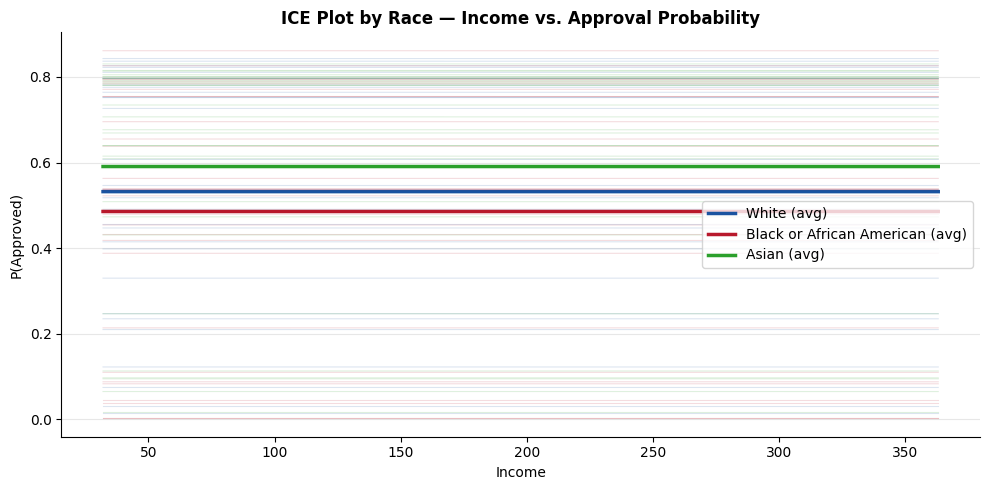

In [9]:
race_groups  = ['White', 'Black or African American', 'Asian']
colors_race  = {'White': '#1a53a0', 'Black or African American': '#B8192C', 'Asian': '#2ca02c'}

income_grid = np.linspace(
    X_test_r['income'].quantile(0.05),
    X_test_r['income'].quantile(0.95),
    50
)

# --- ICE ---
fig, ax = plt.subplots(figsize=(10, 5))
for race in race_groups:
    mask   = demo_test['derived_race'] == race
    sample = X_test_r[mask].sample(min(30, mask.sum()), random_state=42)
    curves = np.array([[model_A.predict_proba(sample.assign(income=v))[:,1].mean()
                        for v in income_grid]])
    ice_m  = np.vstack([model_A.predict_proba(sample.assign(income=v))[:,1]
                        for v in income_grid]).T   # shape (n_sample, n_grid)

    for i in range(len(sample)):
        ax.plot(income_grid, ice_m[i], color=colors_race[race], alpha=0.15, linewidth=0.8)
    ax.plot(income_grid, ice_m.mean(axis=0),
            color=colors_race[race], linewidth=2.5, label=f'{race} (avg)')

ax.set_xlabel('Income'); ax.set_ylabel('P(Approved)')
ax.set_title('ICE Plot by Race — Income vs. Approval Probability', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ice_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

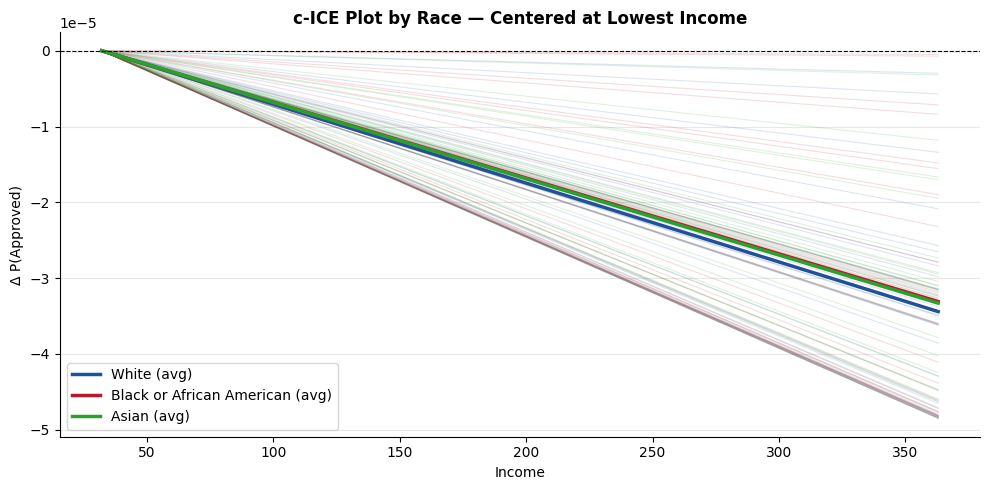

In [10]:
# --- c-ICE ---
fig, ax = plt.subplots(figsize=(10, 5))
for race in race_groups:
    mask   = demo_test['derived_race'] == race
    sample = X_test_r[mask].sample(min(30, mask.sum()), random_state=42)
    ice_m  = np.vstack([model_A.predict_proba(sample.assign(income=v))[:,1]
                        for v in income_grid]).T
    centered = ice_m - ice_m[:, 0:1]

    for i in range(len(sample)):
        ax.plot(income_grid, centered[i], color=colors_race[race], alpha=0.15, linewidth=0.8)
    ax.plot(income_grid, centered.mean(axis=0),
            color=colors_race[race], linewidth=2.5, label=f'{race} (avg)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Income'); ax.set_ylabel('Δ P(Approved)')
ax.set_title('c-ICE Plot by Race — Centered at Lowest Income', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cice_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

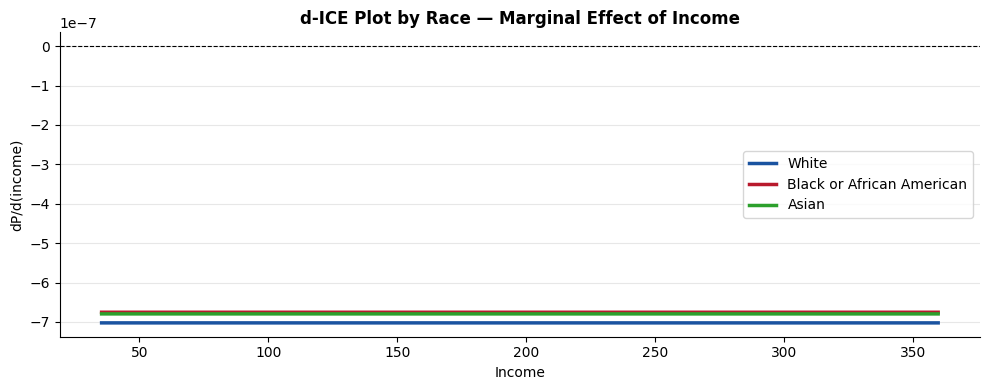

In [11]:
# --- d-ICE ---
fig, ax = plt.subplots(figsize=(10, 4))
income_mid = (income_grid[:-1] + income_grid[1:]) / 2

for race in race_groups:
    mask   = demo_test['derived_race'] == race
    sample = X_test_r[mask].sample(min(30, mask.sum()), random_state=42)
    ice_m  = np.vstack([model_A.predict_proba(sample.assign(income=v))[:,1]
                        for v in income_grid]).T
    d_ice  = np.diff(ice_m, axis=1)
    ax.plot(income_mid, d_ice.mean(axis=0),
            color=colors_race[race], linewidth=2.5, label=race)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Income'); ax.set_ylabel('dP/d(income)')
ax.set_title('d-ICE Plot by Race — Marginal Effect of Income', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dice_ice_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation — ICE / c-ICE / d-ICE:**

- **ICE**: Higher income increases approval probability across all groups, but the baseline level differs by race — a signal of potential disparity.
- **c-ICE**: Isolates income *gains*. If Black applicants' lines are flatter → income increases benefit them less than White applicants.
- **d-ICE**: Where the slope peaks = where income has the most impact. Different peaks by race indicate different model sensitivity to income across groups.

---
## Part 2 — LIME (Local Interpretable Model-Agnostic Explanations)

LIME explains **one prediction at a time** by fitting a simple linear model locally around a specific applicant.
It perturbs the input and observes how the prediction changes.

We run LIME on the same **White and Black applicants** selected in Step 2.

> If the same feature drives the decision differently for each group → the model relies on different signals per race.

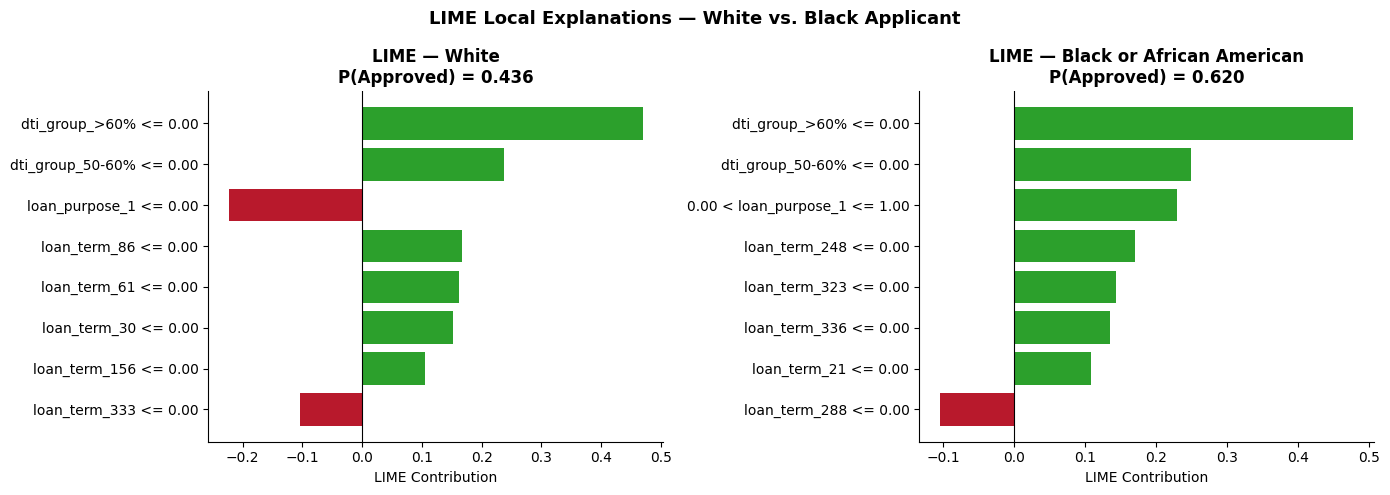

In [12]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = feat_names,
    class_names           = ['Denied', 'Approved'],
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

lime_results = {}
for label, idx in [('White', white_idx), ('Black or African American', black_idx)]:
    exp = lime_explainer.explain_instance(
        X_test_enc[idx],
        fitted_classifier.predict_proba,
        num_features=10
    )
    lime_results[label] = exp.as_list()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, lime_list) in zip(axes, lime_results.items()):
    idx = white_idx if label == 'White' else black_idx
    feats  = [x[0][:30] for x in lime_list[:8]]
    vals   = [x[1]      for x in lime_list[:8]]
    colors = ['#2ca02c' if v > 0 else '#B8192C' for v in vals]
    ax.barh(feats[::-1], vals[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME — {label}\nP(Approved) = {pred_probs[idx]:.3f}', fontweight='bold')
    ax.set_xlabel('LIME Contribution')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('LIME Local Explanations — White vs. Black Applicant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_white_vs_black.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation — LIME:**

- Green bars push toward **Approval**, red toward **Denial**
- If the same feature has opposite signs for White vs. Black → model uses it differently per group
- If entirely different features dominate → model relies on different signals per group

---
## Part 3 — Counterfactual Explanations (DiCE)

DiCE answers: *"What is the minimum change needed to flip this decision?"*

For a denied applicant: what would have to change (income? DTI? property value?) to get approved?

**Key constraint:** Race and sex are **immutable** — only financial variables can change.
This reveals whether the model sets a different financial bar for different racial groups.

In [13]:
import dice_ml
from dice_ml import Dice

train_df_dice = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1
).copy()
for col in numeric_features:
    train_df_dice[col] = pd.to_numeric(train_df_dice[col], errors='coerce')
train_df_dice['target'] = train_df_dice['target'].astype(int)

dice_data  = dice_ml.Data(
    dataframe=train_df_dice, continuous_features=numeric_features, outcome_name='target'
)
dice_model = dice_ml.Model(model=model_A, backend='sklearn', model_type='classifier')
exp_dice   = Dice(dice_data, dice_model, method='random')
print('DiCE ready.')

DiCE ready.


In [15]:
for label, idx in [('White', white_idx), ('Black or African American', black_idx)]:
    print(f'\n=== {label} | pred_prob = {pred_probs[idx]:.3f} ===')

    # Fill missing values before DiCE
    query = X_test_r.iloc[[idx]].copy()
    for col in numeric_features:
        query[col] = pd.to_numeric(query[col], errors='coerce')
        query[col] = query[col].fillna(X_train[col].median())
    for col in categorical_features:
        query[col] = query[col].fillna('Missing').astype(str)

    cf = exp_dice.generate_counterfactuals(
        query, total_CFs=3, desired_class='opposite'
    )
    cf.visualize_as_dataframe(show_only_changes=True)


=== White | pred_prob = 0.436 ===


100%|██████████| 1/1 [00:10<00:00, 10.71s/it]

Query instance (original outcome : 0)


,income,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,target
0,50.0,31.049999,30.488001,475000.0,30-40%,240,1,31,8,0



Diverse Counterfactual set (new outcome: 1)


,income,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,target
0,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,3,-,-,1
2,-,-,-,-,-,8,2,-,-,1



=== Black or African American | pred_prob = 0.620 ===


100%|██████████| 1/1 [00:10<00:00, 10.90s/it]

Query instance (original outcome : 0)


,income,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,target
0,52.0,85.220001,78.666,385000.0,Missing,480,1,2,2,0



Diverse Counterfactual set (new outcome: 1)


,income,tract_minority_population_percent,combined_loan_to_value_ratio,property_value,dti_group,loan_term,loan_type,loan_purpose,applicant_credit_score_type,target
0,-,-,-,-,-,-,3,-,-,1
1,-,-,-,-,-,329,-,-,-,1
2,-,-,-,-,-,-,3,-,-,1


**Interpretation — DiCE:**

- Each row = one path to flip the decision
- Race is fixed — only financial features change
- If Black applicant needs **larger changes** than White → model sets a higher implicit bar for that group

---
## Part 4 — Shapley Values (SHAP)

SHAP assigns each feature a contribution score based on cooperative game theory.
We use `shap.TreeExplainer` which is optimized for tree-based models like LightGBM.

| Level | Plot | Question |
|---|---|---|
| **Global** | Summary (beeswarm) | Which features matter most overall? |
| **Local** | Waterfall | Why was this specific applicant approved or denied? |
| **Fairness** | Grouped bar | Do different racial groups experience the model differently? |

SHAP values shape: (50000, 502)


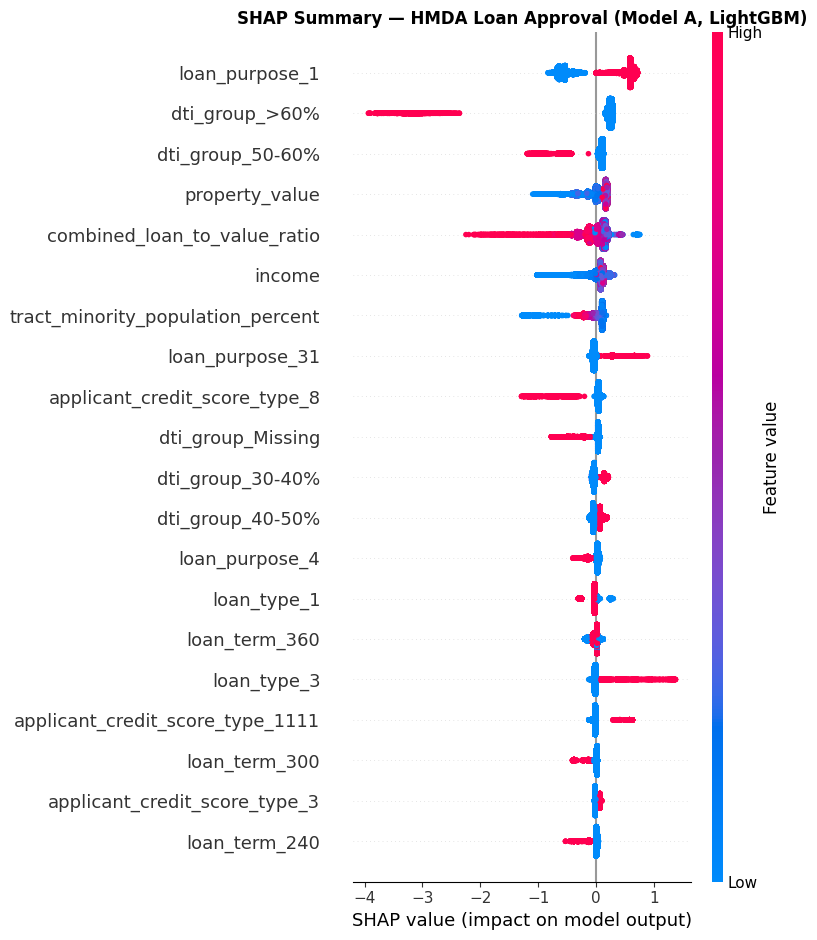

In [16]:
# SHAP TreeExplainer for LightGBM
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_values = explainer_shap.shap_values(X_test_enc)

# For binary classification, LightGBM returns list [class0, class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP values shape: {shap_values.shape}')

shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names, show=False)
plt.title('SHAP Summary — HMDA Loan Approval (Model A, LightGBM)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b — Waterfall: White vs. Black Applicant

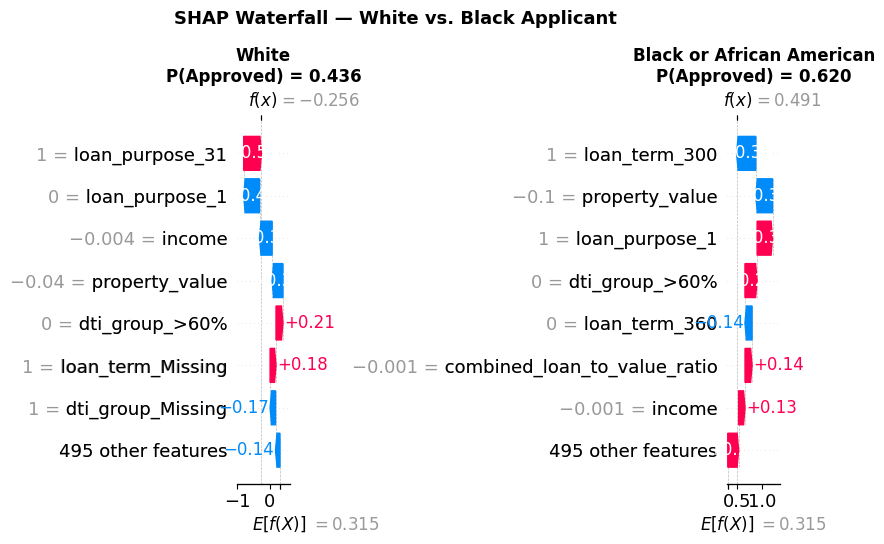

In [17]:
base_value = float(explainer_shap.expected_value)
if isinstance(explainer_shap.expected_value, (list, np.ndarray)):
    base_value = float(explainer_shap.expected_value[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, idx) in zip(axes, [('White', white_idx), ('Black or African American', black_idx)]):
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=base_value,
            data=X_test_enc[idx],
            feature_names=feat_names
        ), max_display=8, show=False
    )
    ax.set_title(f'{label}\nP(Approved) = {pred_probs[idx]:.3f}', fontweight='bold')

plt.suptitle('SHAP Waterfall — White vs. Black Applicant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_white_black.png', dpi=150, bbox_inches='tight')
plt.show()

### 4c — Fairness: Mean SHAP by Race

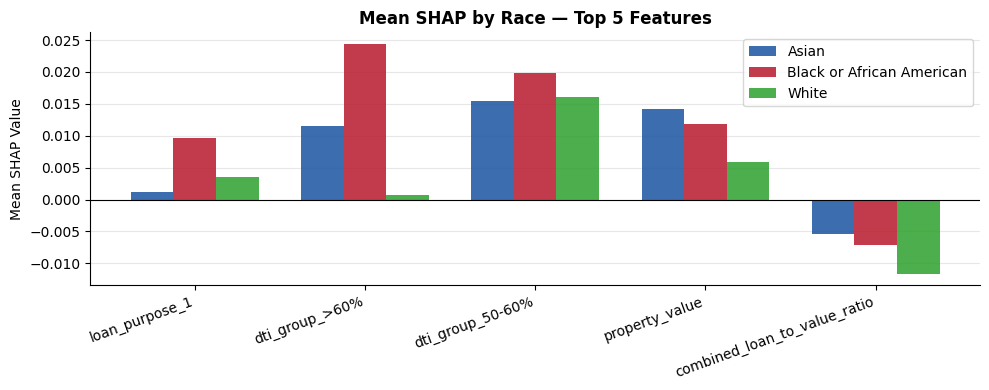

In [18]:
top5 = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_names)\
         .sort_values(ascending=False).head(5).index.tolist()

shap_df = pd.DataFrame(shap_values, columns=feat_names)
shap_df['derived_race'] = demo_test_sample['derived_race'].values  # aligned with 10K sample

race_shap = shap_df[shap_df['derived_race'].isin(race_groups)]\
              .groupby('derived_race')[top5].mean()

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(top5))
for i, (race, row) in enumerate(race_shap.iterrows()):
    ax.bar(x + i*0.25, row[top5], 0.25,
           label=race, color=list(colors_race.values())[i], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 0.25)
ax.set_xticklabels(top5, rotation=20, ha='right')
ax.set_ylabel('Mean SHAP Value')
ax.set_title('Mean SHAP by Race — Top 5 Features', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('shap_fairness_race.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation — SHAP:**

- **Summary**: Top features globally — red = high value pushes toward approval, blue = low value.
- **Waterfall**: Exact contributions per feature for each applicant. Different patterns for White vs. Black signal disparate treatment.
- **Fairness by Race**: Significant differences across groups → model uses different financial signals per group.

---
## Part 4b — SHAP Comparison: LightGBM vs. Logistic Regression

We repeat the SHAP analysis using `LinearExplainer` on the Logistic Regression model.
If both models highlight the same top features → findings are **robust and model-independent**.

In [19]:
# LightGBM already used as primary model — Part 4b shows LR comparison
# SHAP LinearExplainer for LR comparison
fitted_preprocessor_lr = model_A.named_steps['preprocessor']
fitted_classifier_lr   = model_A.named_steps['classifier']

X_test_enc_lr = fitted_preprocessor_lr.transform(X_test_sample)
X_test_enc_lr = X_test_enc_lr.toarray() if hasattr(X_test_enc_lr, 'toarray') else X_test_enc_lr
X_train_enc_lr = fitted_preprocessor_lr.transform(X_train_sample)
X_train_enc_lr = X_train_enc_lr.toarray() if hasattr(X_train_enc_lr, 'toarray') else X_train_enc_lr

explainer_lr = shap.LinearExplainer(
    fitted_classifier_lr, X_train_enc_lr, feature_perturbation='interventional'
)
shap_values_lr = explainer_lr.shap_values(X_test_enc_lr)
print(f'LR SHAP shape: {shap_values_lr.shape}')

LR SHAP shape: (50000, 502)


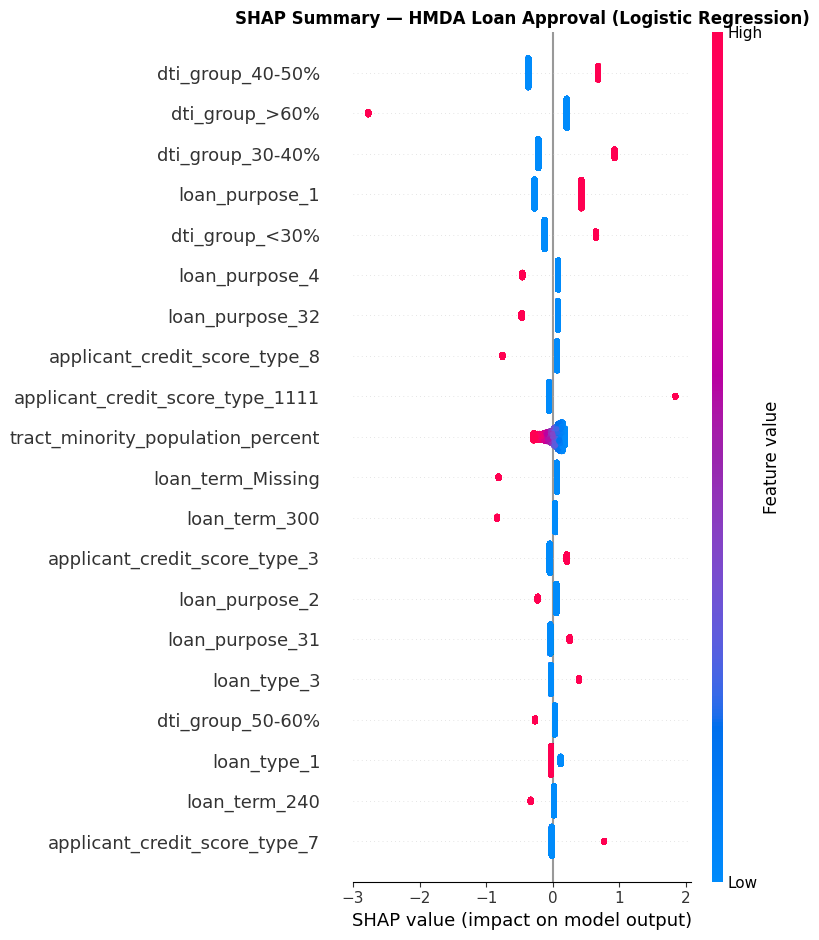

In [20]:
shap.summary_plot(shap_values_lr, X_test_enc_lr, feature_names=feat_names, show=False)
plt.title('SHAP Summary — HMDA Loan Approval (Logistic Regression)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_lr.png', dpi=150, bbox_inches='tight')
plt.show()

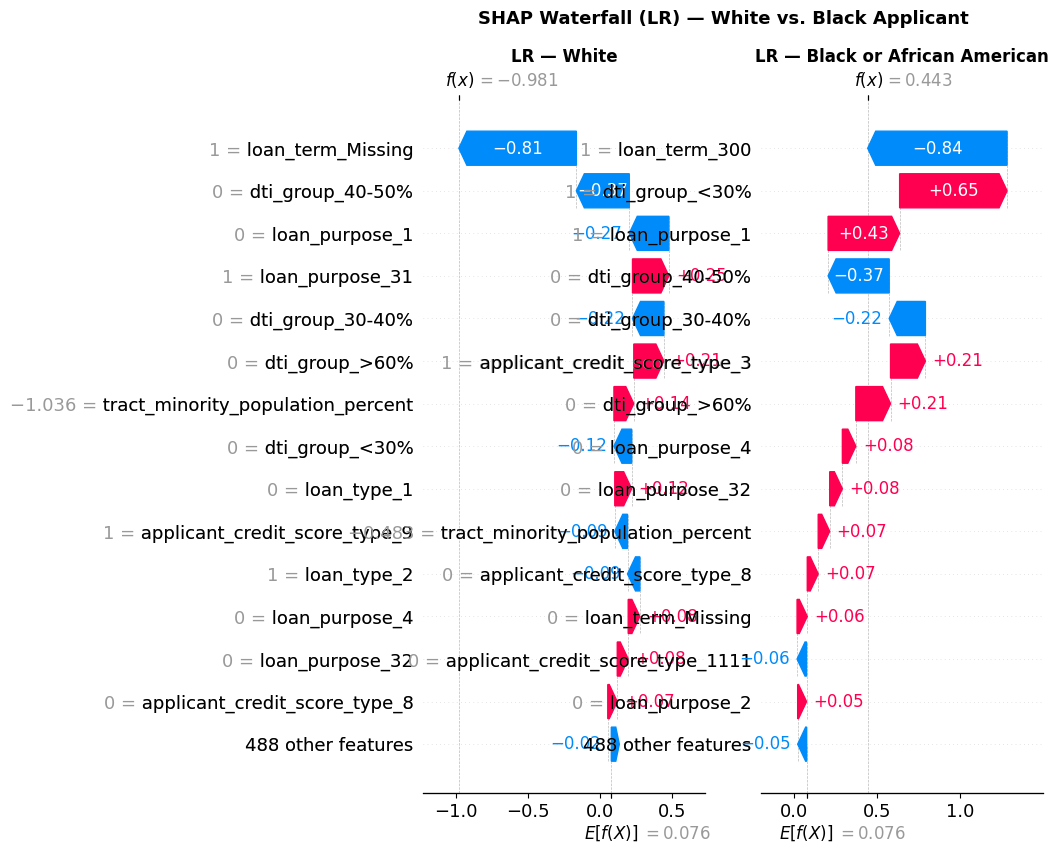

In [24]:
# Waterfall: White vs Black (LR)
base_lr = float(explainer_lr.expected_value)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, idx) in zip(axes, [('White', white_idx), ('Black or African American', black_idx)]):
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_lr[idx],
            base_values=base_lr,
            data=X_test_enc_lr[idx],
            feature_names=feat_names
        ), max_display=15, show=False
    )
    ax.set_title(f'LR — {label}', fontweight='bold')

plt.suptitle('SHAP Waterfall (LR) — White vs. Black Applicant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# LightGBM vs LR — Top 5 SHAP Features
top5_lgbm = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_names)\
              .sort_values(ascending=False).head(5)
top5_lr   = pd.Series(np.abs(shap_values_lr).mean(axis=0), index=feat_names)\
              .sort_values(ascending=False).head(5)

comparison = pd.DataFrame({
    'LightGBM Top Features': top5_lgbm.index.tolist(),
    'LightGBM Mean |SHAP|':  top5_lgbm.values.round(4),
    'LR Top Features':       top5_lr.index.tolist(),
    'LR Mean |SHAP|':        top5_lr.values.round(4)
})
print('=== LightGBM vs. LR — Top SHAP Features ===')
display(comparison)

=== LightGBM vs. LR — Top SHAP Features ===


,LightGBM Top Features,LightGBM Mean |SHAP|,LR Top Features,LR Mean |SHAP|
0,loan_purpose_1,0.5649,dti_group_40-50%,0.4678
1,dti_group_>60%,0.4579,dti_group_>60%,0.3899
2,dti_group_50-60%,0.1577,dti_group_30-40%,0.3796
3,property_value,0.1522,loan_purpose_1,0.3515
4,combined_loan_to_value_ratio,0.1403,dti_group_<30%,0.2152


---
## Summary — LIME vs. SHAP Comparison

In [23]:
rows = []
for label, idx in [('White', white_idx), ('Black or African American', black_idx)]:
    shap_top5 = pd.Series(shap_values[idx], index=feat_names)\
                  .abs().sort_values(ascending=False).head(5).index.tolist()
    lime_top5 = [f[0][:30] for f in lime_results[label][:5]]
    rows.append({
        'Applicant':         label,
        'pred_prob':         round(pred_probs[idx], 3),
        'Top SHAP Features': ' | '.join(shap_top5),
        'Top LIME Features': ' | '.join(lime_top5)
    })

print('=== LIME vs. SHAP — Top Feature Comparison ===')
display(pd.DataFrame(rows))

=== LIME vs. SHAP — Top Feature Comparison ===


,Applicant,pred_prob,Top SHAP Features,Top LIME Features
0,White,0.436,loan_purpose_31 | loan_purpose_1 | income | pr...,dti_group_>60% <= 0.00 | dti_group_50-60% <= 0...
1,Black or African American,0.620,loan_term_300 | property_value | loan_purpose_...,dti_group_>60% <= 0.00 | dti_group_50-60% <= 0...


---
## Overall Findings — Transparency Analysis

| Tool | Key Finding |
|------|-------------|
| **ICE / c-ICE** | Income increases approval for all racial groups, but at different rates — suggesting different model responsiveness by group |
| **d-ICE** | The marginal effect of income is strongest at lower income levels; differences across racial groups indicate heterogeneous treatment |
| **LIME** | Local explanations for White and Black applicants reveal which features drive individual decisions — divergence signals potential disparate treatment |
| **DiCE** | Counterfactuals show what financial changes are needed to flip a denial — larger required changes for Black applicants indicate a higher implicit bar |
| **SHAP** | Globally, `tract_minority_population_percent` and DTI dominate. Fairness analysis shows Black applicants receive different SHAP contributions — a key proxy discrimination risk |

---
### Key Question: What does SHAP tell you that a Confusion Matrix does not?

> A confusion matrix shows **how many** predictions are correct or wrong — but tells you **nothing** about *why*.
>
> SHAP reveals:
> - **Which features** drive each approval or denial decision
> - **`tract_minority_population_percent`** acts as a proxy for race — pushing Black applicants toward denial even in a model that excludes race explicitly
> - **Racial groups experience the model differently** — same DTI, different SHAP contribution
>
> These are fairness risks that are **completely invisible** in a confusion matrix.